# Native Multimodal Fusion: Gemma 4 E4B

Hateful meme detection, zero-shot. One transformer reads image + caption together (joint fusion).
`P(hateful)` from the Yes/No logits, so AUROC is computable. Eval: first 100 of `dev_seen`.

In [1]:
!pip install "transformers>=5.10.2" accelerate bitsandbytes
!pip install scikit-learn tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 16.9 MB/s eta 0:00:00


In [12]:
import json
import torch
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.notebook import tqdm
from huggingface_hub import login
from transformers import AutoProcessor, AutoModelForImageTextToText, BitsAndBytesConfig
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, roc_curve
from google.colab import drive, userdata, files

In [4]:
login(token=userdata.get("HF_TOKEN"))
print("Logged into HuggingFace")

Logged into HuggingFace


## Configuration

In [5]:
MODEL_NAME      = "google/gemma-4-E4B-it"
DRIVE_DATA_PATH = "/content/drive/MyDrive/IIS Project/Data"

QUESTION = ("This is a meme. Look at the image and the caption together. "
            "Is it hateful? Answer with a single word: Yes or No.")

## Data

Frozen 100-meme eval set from Drive (`eval_100.jsonl` + `images/`).

In [6]:
drive.mount('/content/drive')

with open(f"{DRIVE_DATA_PATH}/eval_100.jsonl", encoding="utf-8") as f:
    dataset = [json.loads(l) for l in f]

def load_image(row):
    return Image.open(f"{DRIVE_DATA_PATH}/{row['img']}").convert("RGB")

print(f"Loaded {len(dataset)} memes | hateful: {sum(r['label'] for r in dataset)}")
dataset[0]

Mounted at /content/drive
Loaded 100 memes | hateful: 58


{'id': '01268',
 'img': 'images/01268.png',
 'label': 0,
 'text': 'father and daughter bonding time is the best like and share if you agree'}

## Model

In [7]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
)

processor = AutoProcessor.from_pretrained(MODEL_NAME)
model = AutoModelForImageTextToText.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
)
model.eval()
print(f"Model loaded: {MODEL_NAME}")
print(f"GPU memory used: {torch.cuda.memory_allocated() / 1e9:.2f} GB")

processor_config.json:   0%|          | 0.00/1.69k [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/17.3k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/5.14k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.10k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/32.2M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/16.0G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/2076 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/208 [00:00<?, ?B/s]

Model loaded: google/gemma-4-E4B-it
GPU memory used: 9.52 GB


## Inference

Yes/No token ids (case + leading-space variants), then one forward pass per meme reading the logits
at the first answer position. `P(hateful) = softmax([no, yes])[1]`.

In [8]:
def token_ids(words):
    ids = {processor.tokenizer.encode(w, add_special_tokens=False)[0] for w in words}
    return sorted(ids)

YES_IDS = token_ids(["Yes", " Yes", "yes", " yes"])
NO_IDS  = token_ids(["No", " No", "no", " no"])

@torch.no_grad()
def hateful_prob(image, caption):
    messages = [{"role": "user", "content": [
        {"type": "image", "image": image},
        {"type": "text",  "text": f'Caption: "{caption}"\n{QUESTION}'},
    ]}]
    inputs = processor.apply_chat_template(
        messages, add_generation_prompt=True, tokenize=True,
        return_dict=True, return_tensors="pt",
    ).to(model.device)

    logits = model(**inputs).logits[0, -1, :].float()
    yes = torch.logsumexp(logits[YES_IDS], dim=0)
    no  = torch.logsumexp(logits[NO_IDS],  dim=0)
    return torch.softmax(torch.stack([no, yes]), dim=0)[1].item()

In [9]:
probs, labels = [], []
for row in tqdm(dataset, desc="Scoring"):
    probs.append(hateful_prob(load_image(row), row["text"]))
    labels.append(int(row["label"]))

preds = [int(p >= 0.5) for p in probs]

Scoring:   0%|          | 0/100 [00:00<?, ?it/s]

## Results

In [10]:
results = pd.DataFrame([{
    "model":    "Gemma 4 E4B (native multimodal)",
    "AUROC":    round(roc_auc_score(labels, probs), 4),
    "Accuracy": round(accuracy_score(labels, preds), 4),
    "F1":       round(f1_score(labels, preds), 4),
    "n":        len(labels),
}])
results

,model,AUROC,Accuracy,F1,n
0,Gemma 4 E4B (native multimodal),0.7461,0.56,0.4211,100


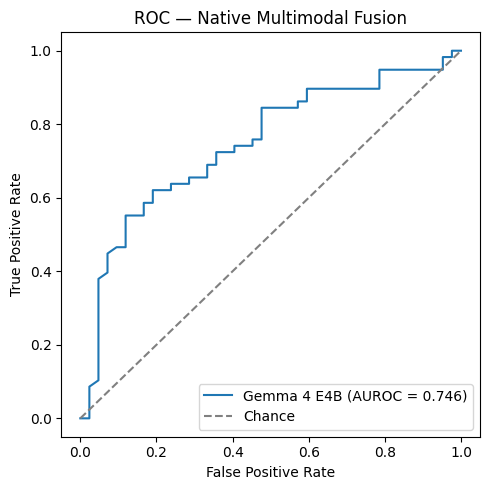

In [13]:
fpr, tpr, _ = roc_curve(labels, probs)
auc = roc_auc_score(labels, probs)

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"Gemma 4 E4B (AUROC = {auc:.3f})")
plt.plot([0, 1], [0, 1], "--", color="gray", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC — Native Multimodal Fusion")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [11]:
pd.DataFrame({
    "id": [r["id"] for r in dataset],
    "label": labels, "prob_hateful": probs, "pred": preds,
}).to_csv("gemma4_predictions.csv", index=False)
files.download("gemma4_predictions.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>